In [1]:

import os
hf_token = os.getenv("HF_TOKEN")

import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import gensim.downloader     #na nacitanie predtrenovaneho word2vec modelu
from nltk.tokenize import word_tokenize
import nltk     #natural language processing
nltk.download('punkt', quiet=True)

from src.data_loader import load_data
from src.LM.embeddings.embedder_preprocess import clean_text
from src.LM.embeddings.embedder_preprocess import load_word2vec_model
from src.LM.embeddings.embedder_preprocess import text_to_vector
from src.LM.embeddings.embedder_preprocess import prepare_data_word2vec



In [2]:
# nacitanie datasetu

df = load_data("/home/xkubanova_126831/bakalarka/e_com_dataset/data/ecommerceDataset.csv")

Dataset shape: (50425, 2)

Categories samples:

Books:
  Inner Engineering: A Yogi's Guide to Joy About the Author Sadhguru Jaggi VasudevSADHGURU is a yogi, mystic, and visionary who established the Isha Foundation, a nonprofit dedicated to the cultivation of human potential. He belongs to no particular tradition, and his scientific methods for self-transformation have universal appeal. Sadhguru has been an in?uential voice at global forums including th...

Clothing & Accessories:
  Woopower 36M Pink for 024M Baby Trouser Top Sets3Pcs Boy Girl Hooded Topsstriped Pantshairband Outfits36Mpink Size name36m colourpink description100 brand new and type children setgender unisexfor season autumn springcoloroptional pink greensize table 7080 90 100cminchsize tops length bust pants length age70 32 1260 46 1811 37 1457 36m80 34 1339 48 1890 39 1535 612m90 36 1417 52 2047 41 1614 1218m...

Electronics:
  Dell 19.5V-3.34AMP 65W Laptop Adapter (Without power Cord) Design Features of Dell Laptop - 

In [3]:
# nacitanie predtrenovaneho modelu Word2Vec (300 dimenzionalny) 
model = load_word2vec_model()
print("Model loaded. Vector size:", model.vector_size) # 300

Loading pretrained Word2Vec model from gensim…
Model loaded
Model loaded. Vector size: 300


In [4]:
# nacitanie predtrenovaneho modelu MiniLM
import torch
from src.LM.embeddings.embedder_preprocess import load_minilm_embedder

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer, minilm_model = load_minilm_embedder("sentence-transformers/all-MiniLM-L6-v2", device=device )

Loading pretrained BERT model 'sentence-transformers/all-MiniLM-L6-v2' from Hugging Face…
BERT embedder loaded on device: cuda


In [5]:
# ukazkovy text na zobrazenie embeddingu - Word2Vec
# veta -> vektor
# slova sa tokenizuju
# kazdemu slovu sa priradi vektor podla word2vec modelu
# vektory slov sa spriemeruju -> vektor pre celu vetu
# vystup je 300- dimenzionalny vektor

from src.LM.embeddings.embedder_preprocess import text_to_vector_word


example_text1 = "Apple is a fruit that grows on a tree."
example_text2 = "Apple released a new version of iPhone."

embedding1 = text_to_vector_word(example_text1, model)
print("Embedding1 shape:", embedding1.shape)
print("First 10 dimensions:", embedding1[:10])

embedding2 = text_to_vector_word(example_text2, model)
print("Embedding1 shape:", embedding2.shape)
print("First 10 dimensions:", embedding2[:10])

Embedding1 shape: (300,)
First 10 dimensions: [-0.17480469  0.0300293  -0.21679688  0.15625    -0.35742188 -0.06054688
  0.13671875  0.09570312  0.00317383 -0.04296875]
Embedding1 shape: (300,)
First 10 dimensions: [-0.17480469  0.0300293  -0.21679688  0.15625    -0.35742188 -0.06054688
  0.13671875  0.09570312  0.00317383 -0.04296875]


In [6]:
# ukazkovy text na zobrazenie embeddingu - MiniLM
# veta -> vektor


from src.LM.embeddings.embedder_preprocess import text_to_vector_minilm


example_text1 = "Apple is a fruit that grows on a tree."
example_text2 = "Apple released a new version of iPhone."


embedding1 = text_to_vector_minilm(example_text1, tokenizer, minilm_model, device=device)
print("Embedding1 shape:", embedding1.shape)
print("First 10 dimensions:", embedding1[:10])

embedding2 = text_to_vector_minilm(example_text2, tokenizer, minilm_model, device=device)
print("Embedding2 shape:", embedding2.shape)
print("First 10 dimensions:", embedding2[:10])

Embedding1 shape: (384,)
First 10 dimensions: [ 0.4502699   0.18886605  0.16646534  0.14955494  0.05059973 -0.12807535
  0.12020363 -0.06743618  0.20546685  0.13959308]
Embedding2 shape: (384,)
First 10 dimensions: [ 0.15260333 -0.05435698  0.5314298  -0.13960566 -0.167904   -0.20911597
  0.04767897  0.06429517  0.2427238   0.08269416]


Loading pretrained Word2Vec model from gensim…


/tmp/ipykernel_2950894/1906803110.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 100), random_state=42))


Model loaded

 Embeddings ready:
Train embeddings shape: (320, 300)
Test embeddings shape: (80, 300)


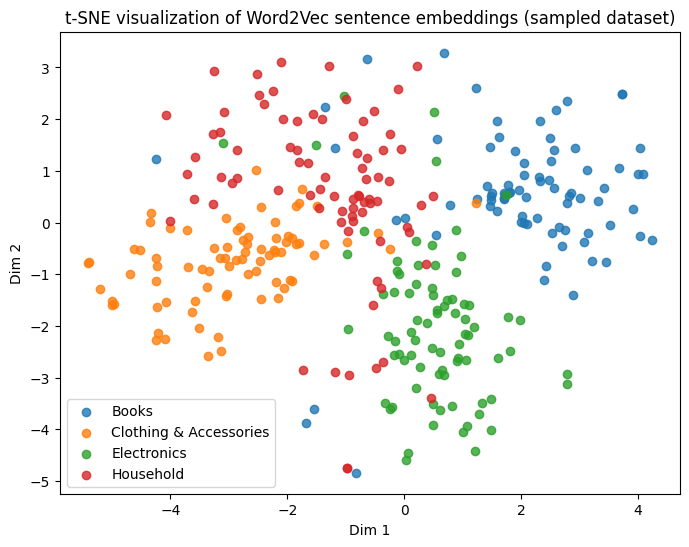

In [7]:

# vyber mensieho poctu vzoriek - 30 vzoriek z kazdej kategorie
sampled_df = (
    df.groupby("Category", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), 100), random_state=42))
      .reset_index(drop=True)
)



# vytvorenie embeddingov
# vycistenie textu
# rozdelenie na train / test
# nacitanie modelu
# konvertovanie kazdej vety na 300-dimenzionanlny vector
X_train_vec, X_test_vec, y_train, y_test, model = prepare_data_word2vec(sampled_df)
print("\n Embeddings ready:")
print("Train embeddings shape:", X_train_vec.shape)
print("Test embeddings shape:", X_test_vec.shape)

# t-SNE vizualizacia (distributed stochastic neighbour embedding)
# 300D -> 2D reprezentacia

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# perplexity musi byt menej ako pocet vzoriek
# kolko blizkych bodov povazuje bod za svojich susedov
perplexity = min(100, len(X_train_vec) - 1)

tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
X_tsne = tsne.fit_transform(X_train_vec)

# vizualizacia 
# bodka - jedna vzorka (veta)
# podobne vety (z rovnakej kategorie) su blizko pri sebe
plt.figure(figsize=(8,6))
for label in np.unique(y_train):
    idx = np.where(y_train == label)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.8)

plt.title("t-SNE visualization of Word2Vec sentence embeddings (sampled dataset)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.show()



/tmp/ipykernel_2950894/57340999.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 100), random_state=42))
Encoding batches:   0%|          | 0/10 [00:00<?, ?it/s]

Encoding batches: 100%|██████████| 3/3 [00:00<00:00, 69.52it/s]



 Embeddings ready:
Train embeddings shape: (320, 384)
Test embeddings shape: (80, 384)


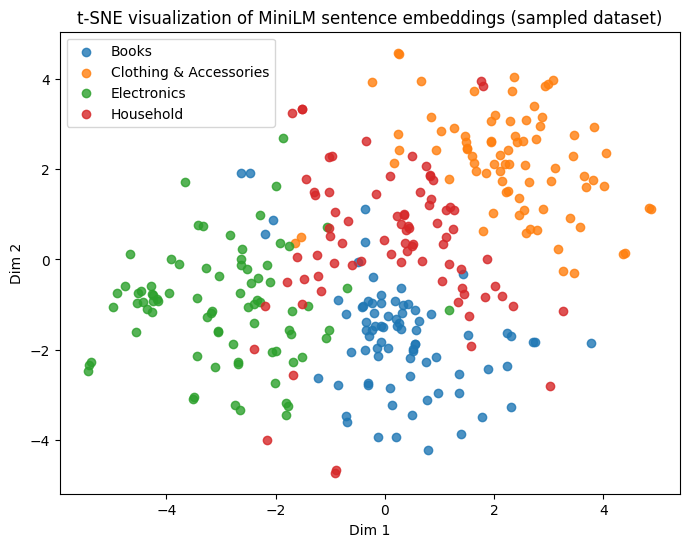

In [8]:

# vyber mensieho poctu vzoriek - 30 vzoriek z kazdej kategorie
from src.LM.embeddings.embedder_preprocess import prepare_data_minilm


sampled_df = (
    df.groupby("Category", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), 100), random_state=42))
      .reset_index(drop=True)
)



# vytvorenie embeddingov
# vycistenie textu
# rozdelenie na train / test
# nacitanie modelu

X_train_vec, X_test_vec, y_train, y_test = prepare_data_minilm(sampled_df, tokenizer, minilm_model, device = device, batch_size = 32)
print("\n Embeddings ready:")
print("Train embeddings shape:", X_train_vec.shape)
print("Test embeddings shape:", X_test_vec.shape)

# t-SNE vizualizacia (distributed stochastic neighbour embedding)
# 300D -> 2D reprezentacia

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# perplexity musi byt menej ako pocet vzoriek
# kolko blizkych bodov povazuje bod za svojich susedov
perplexity = min(100, len(X_train_vec) - 1)

tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
X_tsne = tsne.fit_transform(X_train_vec)

# vizualizacia 
# bodka - jedna vzorka (veta)
# podobne vety (z rovnakej kategorie) su blizko pri sebe
plt.figure(figsize=(8,6))
for label in np.unique(y_train):
    idx = np.where(y_train == label)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.8)

plt.title("t-SNE visualization of MiniLM sentence embeddings (sampled dataset)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.show()

